In [1]:
import numpy as np
import pickle
from matplotlib import pyplot as plt
import pandas as pd
from scipy import stats
from statsmodels.stats.anova import AnovaRM

In [2]:
def to_day(di):
    if di >= 2:
        return "Day6"
    else:
        return "Day" + str(di + 1)

In [3]:
with open("w_single.pkl", "rb") as f:
    w = pickle.load(f)

In [4]:
rates = [0.8, 0.9, 0.95]
save = np.zeros((6, 3, 10, 3, 3))
ave_save = np.zeros((6, 3, 3))
for mi in range(6):
    mouse = "Mouse ID: {}".format(mi + 1)
    print(mouse)
    for di in range(3):
        print(to_day(di))
        _, k, _ = w[mi][di].shape
        for ki in range(k):
            df = pd.DataFrame(w[mi][di][:, ki, :].copy(), columns=["activity", "time"])
            df["time"] /= 5
            s = df.groupby("time").sum()
            index = s.index.values
            activity = s["activity"].values
            c = np.cumsum(activity)
            for ri, rate in enumerate(rates):
                save[mi, di, ki, ri, 0] = index[np.where(c > rate)[0][0]]
                save[mi, di, ki, ri, 2] = save[mi, di, ki, ri, 0]
                for i in range(50):
                    end = np.where(c > rate + c[i])[0]
                    if len(end) == 0:
                        break
                    if save[mi, di, ki, ri, 0] > index[end[0]] - index[i]:
                        save[mi, di, ki, ri, 0] = index[end[0]] - index[i]
                        save[mi, di, ki, ri, 1] = index[i]
                        save[mi, di, ki, ri, 2] = index[end[0]]
            print("Seq: {:>2} | 80%: {:.1f}s ({:.1f}-{:.1f}), 90%: {:.1f}s ({:.1f}-{:.1f}), 95%: {:.1f}s ({:.1f}-{:.1f})".format(
                ki + 1, save[mi, di, ki, 0, 0], save[mi, di, ki, 0, 1], save[mi, di, ki, 0, 2], 
                save[mi, di, ki, 1, 0], save[mi, di, ki, 1, 1], save[mi, di, ki, 1, 2], 
                save[mi, di, ki, 2, 0], save[mi, di, ki, 2, 1], save[mi, di, ki, 2, 2]))
        ave_save[mi, di, :] = [save[mi, di, :k, 0, 0].mean(), save[mi, di, :k, 1, 0].mean(), save[mi, di, :k, 2, 0].mean()]
        print("Average | 80%: {:.1f}s          , 90%: {:.1f}s          , 95%: {:.1f}s".format(
            ave_save[mi, di, 0], ave_save[mi, di, 1], ave_save[mi, di, 2]
        ), end="\n\n")

    ave = save[mi, :, :, :, 0][save[mi, :, :, :, 0].sum(axis=-1) > 0].mean(axis=0)
    print("{} |Average| 80%: {:.1f}s, 90%: {:.1f}s, 95%: {:.1f}s".format(mouse, ave[0], ave[1], ave[2]), end="\n\n")

for di in range(3):
    tmp = save[:, di, :, :, 0][save[:, di, :, :, 0].sum(axis=-1) > 0].mean(axis=0)
    print("Avg. {:>5} | 80%: {:.1f}s, 90%: {:.1f}s, 95%: {:.1f}s".format(to_day(di), tmp[0], tmp[1], tmp[2]))
tmp = save[:, :, :, :, 0][save[:, :, :, :, 0].sum(axis=-1) > 0].mean(axis=0)
print("Avg. Total | 80%: {:.1f}s, 90%: {:.1f}s, 95%: {:.1f}s".format(tmp[0], tmp[1], tmp[2]))

Mouse ID: 1
Day1
Seq:  1 | 80%: 3.4s (0.0-3.4), 90%: 8.4s (0.0-8.4), 95%: 9.2s (0.0-9.2)
Seq:  2 | 80%: 9.0s (0.2-9.2), 90%: 9.4s (0.2-9.6), 95%: 9.4s (0.2-9.6)
Seq:  3 | 80%: 7.2s (0.0-7.2), 90%: 8.0s (0.0-8.0), 95%: 9.0s (0.0-9.0)
Seq:  4 | 80%: 4.8s (0.4-5.2), 90%: 5.8s (0.6-6.4), 95%: 7.4s (0.4-7.8)
Seq:  5 | 80%: 7.0s (2.8-9.8), 90%: 8.8s (1.0-9.8), 95%: 9.4s (0.4-9.8)
Seq:  6 | 80%: 5.8s (1.0-6.8), 90%: 6.0s (1.0-7.0), 95%: 6.8s (0.8-7.6)
Average | 80%: 6.2s          , 90%: 7.7s          , 95%: 8.5s

Day2
Seq:  1 | 80%: 3.8s (0.0-3.8), 90%: 6.4s (0.0-6.4), 95%: 7.8s (0.0-7.8)
Seq:  2 | 80%: 5.4s (0.4-5.8), 90%: 7.0s (0.0-7.0), 95%: 8.0s (0.0-8.0)
Seq:  3 | 80%: 5.2s (1.8-7.0), 90%: 6.2s (0.8-7.0), 95%: 7.2s (0.4-7.6)
Seq:  4 | 80%: 7.2s (0.4-7.6), 90%: 8.2s (0.2-8.4), 95%: 8.6s (0.0-8.6)
Average | 80%: 5.4s          , 90%: 7.0s          , 95%: 7.9s

Day6
Seq:  1 | 80%: 6.6s (3.0-9.6), 90%: 7.6s (2.0-9.6), 95%: 9.0s (0.6-9.6)
Seq:  2 | 80%: 5.2s (2.2-7.4), 90%: 6.8s (0.0-6.8), 95%

              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
day  0.3204 2.0000 10.0000 0.7331



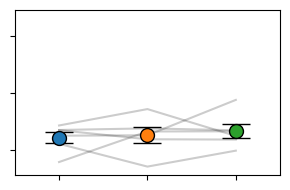

              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
day  0.1012 2.0000 10.0000 0.9047



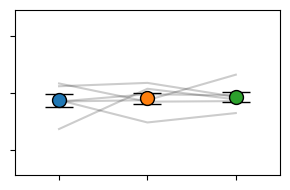

              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
day  0.2384 2.0000 10.0000 0.7922



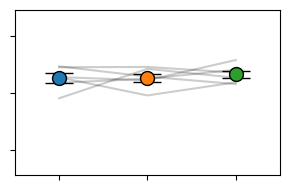

In [5]:
for ci in range(3):
    plt.figure(figsize=(3, 2))
    plt.plot(ave_save[:, :, ci].T, color="black", alpha=0.2, zorder=1)
    df = pd.DataFrame({
        "mouse": np.tile(np.arange(1, 7), 3),
        "duration": ave_save[:, :, ci].T.reshape(-1),
        "day": np.repeat([to_day(di) for di in range(3)], 6),
    })
    print(AnovaRM(data=df, depvar="duration", subject="mouse", within=["day"]).fit())
    for di in range(3):
        plt.errorbar(di, ave_save[:, di, ci].mean(), fmt="o", yerr=stats.sem(ave_save[:, di, ci]), ecolor="black", markeredgecolor="black", color="C"+str(di), markersize=10, capsize=10)
    plt.xticks(np.arange(3))
    plt.yticks([6, 8, 10])
    plt.xlim(-0.5, 2.5)
    plt.ylim(5.1, 10.9)
    plt.tick_params(labelleft=False, labelbottom=False)
    plt.tight_layout()
    plt.savefig("figures/figs6/figs6c_{}.png".format(ci))
    plt.show()

In [6]:
n_cells = [w[mi][0].shape[0] for mi in range(6)]

In [7]:
save = np.zeros((6, 3, 10, 3), dtype=int)
ave_save = np.zeros((6, 3, 3))
for mi in range(6):
    mouse = "Mouse ID: {}".format(mi + 1)
    print("{}, Total Number of Cells: {}".format(mouse, w[mi][0].shape[0]))
    for di in range(3):
        print(to_day(di))
        _, k, _ = w[mi][di].shape
        for ki in range(k):
            c = np.cumsum(np.sort(w[mi][di][:, ki, 0])[::-1])
            save[mi, di, ki, :] = [np.where(c > 0.8)[0][0], np.where(c > 0.9)[0][0], np.where(c > 0.95)[0][0]]
            print("Seq: {:>2} | 80%: {:>5}, 90%: {:>5}, 95%: {:>5}".format(
                ki + 1, save[mi, di, ki, 0], save[mi, di, ki, 1], save[mi, di, ki, 2]))
        ave_save[mi, di, :] = [save[mi, di, :k, 0].mean(), save[mi, di, :k, 1].mean(), save[mi, di, :k, 2].mean()]
        print("Average | 80%: {:>5.1f}, 90%: {:>5.1f}, 95%: {:>5.1f}".format(
            ave_save[mi, di, 0], ave_save[mi, di, 1], ave_save[mi, di, 2]
        ), end="\n\n")

    ave = save[mi, :, :, :][save[mi, :, :, :].sum(axis=-1) > 0].mean(axis=0)
    print("{} |Average| 80%: {:.1f}, 90%: {:.1f}, 95%: {:.1f}".format(mouse, ave[0], ave[1], ave[2]), end="\n\n")
    ave_save[mi, :, :] /= n_cells[mi]

for di in range(3):
    tmp = save[:, di, :, :][save[:, di, :, :].sum(axis=-1) > 0].mean(axis=0)
    print("Avg. {:>5} | 80%: {:.1f}, 90%: {:.1f}, 95%: {:.1f}".format(to_day(di), tmp[0], tmp[1], tmp[2]))
tmp = save[save.sum(axis=-1) > 0].mean(axis=0)
print("Avg. Total | 80%: {:.1f}, 90%: {:.1f}, 95%: {:.1f}".format(tmp[0], tmp[1], tmp[2]))

Mouse ID: 1, Total Number of Cells: 347
Day1
Seq:  1 | 80%:    98, 90%:   126, 95%:   149
Seq:  2 | 80%:   105, 90%:   140, 95%:   168
Seq:  3 | 80%:    86, 90%:   117, 95%:   143
Seq:  4 | 80%:   118, 90%:   154, 95%:   180
Seq:  5 | 80%:   105, 90%:   140, 95%:   165
Seq:  6 | 80%:    76, 90%:   102, 95%:   124
Average | 80%:  98.0, 90%: 129.8, 95%: 154.8

Day2
Seq:  1 | 80%:   122, 90%:   157, 95%:   182
Seq:  2 | 80%:   112, 90%:   146, 95%:   172
Seq:  3 | 80%:   128, 90%:   161, 95%:   186
Seq:  4 | 80%:   110, 90%:   144, 95%:   172
Average | 80%: 118.0, 90%: 152.0, 95%: 178.0

Day6
Seq:  1 | 80%:    89, 90%:   123, 95%:   148
Seq:  2 | 80%:   101, 90%:   143, 95%:   174
Seq:  3 | 80%:   131, 90%:   168, 95%:   193
Seq:  4 | 80%:   111, 90%:   144, 95%:   171
Seq:  5 | 80%:   130, 90%:   164, 95%:   189
Average | 80%: 112.4, 90%: 148.4, 95%: 175.0

Mouse ID: 1 |Average| 80%: 108.1, 90%: 141.9, 95%: 167.7

Mouse ID: 2, Total Number of Cells: 455
Day1
Seq:  1 | 80%:    71, 90%:   

              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
day  0.2122 2.0000 10.0000 0.8123



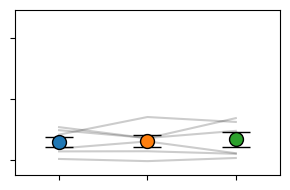

              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
day  0.2462 2.0000 10.0000 0.7864



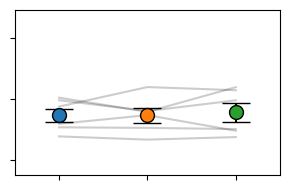

              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
day  0.2312 2.0000 10.0000 0.7977



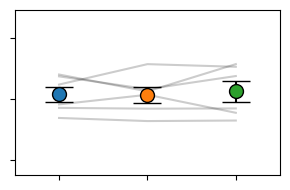

In [8]:
for ci in range(3):
    plt.figure(figsize=(3, 2))
    plt.plot(ave_save[:, :, ci].T, color="black", alpha=0.2, zorder=1)
    df = pd.DataFrame({
        "mouse": np.tile(np.arange(1, 7), 3),
        "proportion": ave_save[:, :, ci].T.reshape(-1),
        "day": np.repeat([to_day(di) for di in range(3)], 6),
    })
    print(AnovaRM(data=df, depvar="proportion", subject="mouse", within=["day"]).fit())
    for di in range(3):
        plt.errorbar(di, ave_save[:, di, ci].mean(), fmt="o", yerr=stats.sem(ave_save[:, di, ci]), ecolor="black", markeredgecolor="black", color="C"+str(di), markersize=10, capsize=10)
    plt.xticks(np.arange(3))
    plt.yticks([0.2, 0.4, 0.6])
    plt.xlim(-0.5, 2.5)
    plt.ylim(0.15, 0.69)
    plt.tick_params(labelleft=False, labelbottom=False)
    plt.tight_layout()
    plt.savefig("figures/figs6/figs6d_{}.png".format(ci))
    plt.show()

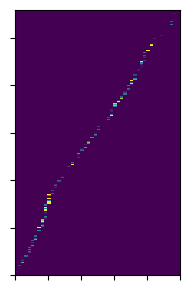

In [9]:
mi = 4
di = 2
ki = 1
wk = w[mi][di][:, ki, :]
n, _ = wk.shape
tmp = np.zeros((n, 50))
for i, (a, p) in enumerate(wk[wk[:, 1].argsort(), :]):
    tmp[i, int(p)] = a
th = wk[:, 0].mean() + 2 * wk[:, 0].std()
plt.figure(figsize=(2, 3))
plt.xticks(np.arange(6) * 10)
plt.yticks(np.arange(6) * 100)
plt.pcolor(tmp, vmin=0, vmax=th)
plt.tick_params(labelleft=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/figs6/figs6a.png")

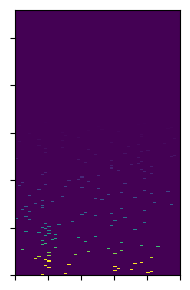

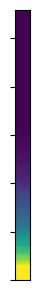

In [10]:
mi = 4
di = 2
ki = 1
wk = w[mi][di][:, ki, :]
n, _ = wk.shape
tmp = np.zeros((n, 50))
s = np.zeros((n, 1))
for i, (a, p) in enumerate(wk[wk[:, 0].argsort()[::-1], :]):
    tmp[i, int(p)] = a
    s[i] = a
th = wk[:, 0].mean() + 2 * wk[:, 0].std()
plt.figure(figsize=(2, 3))
plt.xticks(np.arange(6) * 10)
plt.yticks(np.arange(6) * 100)
plt.pcolor(tmp, vmin=0, vmax=th)
plt.tick_params(labelleft=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/figs6/figs6b.png")
plt.show()
plt.figure(figsize=(0.5, 3))
plt.pcolor(s, vmin=0, vmax=th)
plt.tick_params(labelleft=False, labelbottom=False, bottom=False)
plt.yticks(np.arange(6) * 100)
plt.tight_layout()
plt.savefig("figures/figs6/figs6color.png")